In [1]:
!pip install yfinance


In [2]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime


In [3]:
stock = "HDFCBANK.NS"   # Change anytime

start = "2018-01-01"
end = datetime.today().strftime('%Y-%m-%d')


In [4]:
data = yf.download(stock, start=start, end=end)["Close"]

data.tail()


/tmp/ipykernel_3687/3900181789.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock, start=start, end=end)["Close"]
[*********************100%***********************]  1 of 1 completed


Ticker,HDFCBANK.NS
Date,
2026-04-06,771.000000
2026-04-07,772.000000
2026-04-08,816.099976
2026-04-09,797.700012
2026-04-10,810.299988


In [5]:
log_returns = np.log(1 + data.pct_change()).dropna()

mu = float(log_returns.mean().values[0])
sigma = float(log_returns.std().values[0])

print("Mean:", mu)
print("Volatility:", sigma)



Mean: 0.00030724060724044946
Volatility: 0.015260143751244707


In [6]:
days = 252      # 1 year
simulations = 10000

S0 = float(data.iloc[-1])   # Last price


/tmp/ipykernel_3687/2994319353.py:4: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S0 = float(data.iloc[-1])   # Last price


In [7]:
price_paths = np.zeros((days, simulations))

price_paths[0] = S0


for t in range(1, days):

    Z = np.random.standard_normal(simulations)

    price_paths[t] = price_paths[t-1] * np.exp(
        (mu - 0.5 * sigma**2) +
        sigma * Z
    )


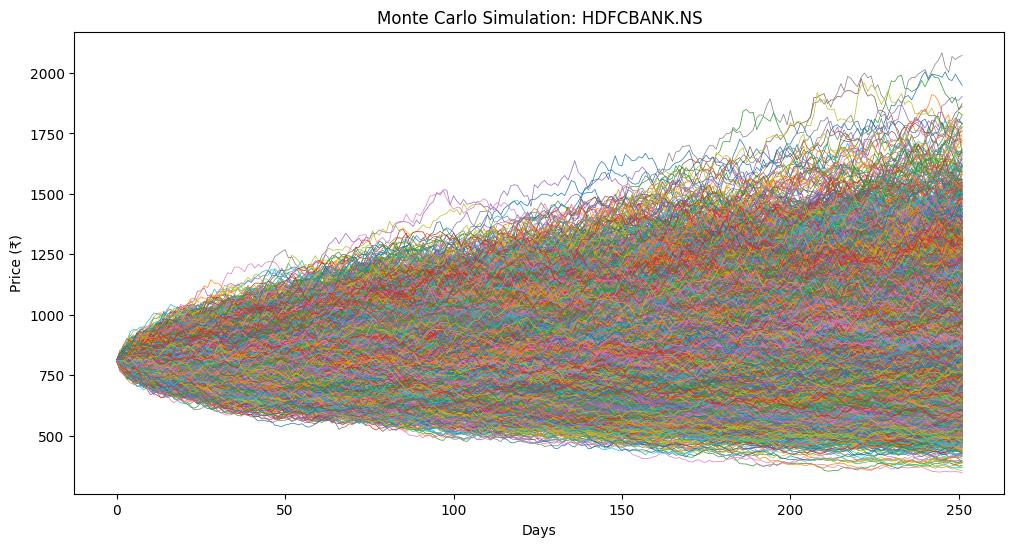

In [8]:
plt.figure(figsize=(12,6))

plt.plot(price_paths, linewidth=0.5)

plt.title(f"Monte Carlo Simulation: {stock}")
plt.xlabel("Days")
plt.ylabel("Price (₹)")

plt.show()


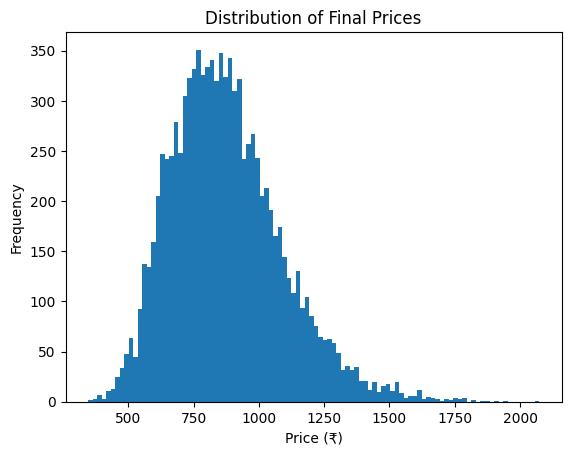

In [9]:
final_prices = price_paths[-1]

plt.hist(final_prices, bins=100)

plt.title("Distribution of Final Prices")
plt.xlabel("Price (₹)")
plt.ylabel("Frequency")

plt.show()


In [10]:
mean_price = np.mean(final_prices)
best_case = np.percentile(final_prices, 95)
worst_case = np.percentile(final_prices, 5)

print("Expected Price:", round(mean_price,2))
print("Best Case (95%):", round(best_case,2))
print("Worst Case (5%):", round(worst_case,2))


Expected Price: 876.99
Best Case (95%): 1268.46
Worst Case (5%): 573.85


In [11]:
loss_prob = np.mean(final_prices < S0)

print("Probability of Loss:", round(loss_prob*100,2), "%")


Probability of Loss: 41.73 %
